In [5]:
!python -m pip install lightgbm pandas scikit-learn matplotlib seaborn

  Using cached pandas-3.0.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached matplotlib-3.10.9-cp314-cp314-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 97.3 kB/s  0:01:41m0:00:0300:06m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 87.1 kB/s  0:01:31 eta 0:00:03m
Using cached matplotlib-3.10.9-cp314-cp314-macosx_11_0_arm64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using 

In [6]:
# Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler


Matplotlib is building the font cache; this may take a moment.


In [7]:
# --- Load the synthetic CDR data ---
df = pd.read_csv('data/cdr_data.csv')
# Before Transformation
df.head(5)

,Caller id,Caller company,Receiver id,Receiver company,Timestamp,Duration s.
0,84034,Safaricom,50880,Safaricom,2025-10-01 05:03,572
1,71646,Safaricom,50331,Safaricom,2025-10-01 05:08,1
2,84292,Safaricom,21396,Telkom,2025-10-01 05:11,205
3,98979,Safaricom,67072,Safaricom,2025-10-01 05:41,117
4,73312,Safaricom,53523,Airtel,2025-10-01 08:23,544


In [8]:
import re
# Rename columns: lowercase and underscores
df.rename(
    columns=lambda x: re.sub(r"[^a-z0-9_]", "", x.strip().lower().replace(" ", "_")),
    inplace=True
)
# Convert Timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [9]:
df.head(1)

,caller_id,caller_company,receiver_id,receiver_company,timestamp,duration_s
0,84034,Safaricom,50880,Safaricom,2025-10-01 05:03:00,572


In [10]:
def engineer_cdr_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create user-level CDR features from raw call records.

    Expected columns:
    - caller_id
    - caller_company
    - receiver_id
    - receiver_company
    - timestamp
    - duration_s
    """

    # Copy to avoid mutating original dataframe
    cdr = df.copy()

    required_cols = [
        "caller_id",
        "caller_company",
        "receiver_id",
        "receiver_company",
        "timestamp",
        "duration_s",
    ]

    missing = [col for col in required_cols if col not in cdr.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Convert data types
    cdr["timestamp"] = pd.to_datetime(cdr["timestamp"], errors="coerce")
    cdr["duration_s"] = pd.to_numeric(cdr["duration_s"], errors="coerce")

    # Drop rows with missing critical fields
    cdr = cdr.dropna(subset=["caller_id", "receiver_id", "timestamp", "duration_s"])
    # -----------------------------
    # 2. Time-based fields
    # -----------------------------
    cdr["call_date"] = cdr["timestamp"].dt.date
    cdr["hour"] = cdr["timestamp"].dt.hour
    cdr["day_of_week"] = cdr["timestamp"].dt.dayofweek  # Monday=0, Sunday=6
    cdr["is_weekend"] = cdr["day_of_week"].isin([5, 6]).astype(int)
    cdr["month"] = cdr["timestamp"].dt.to_period("M").astype(str)

    # Day period buckets
    cdr["is_morning"] = cdr["hour"].between(6, 11).astype(int)
    cdr["is_afternoon"] = cdr["hour"].between(12, 17).astype(int)
    cdr["is_evening"] = cdr["hour"].between(18, 23).astype(int)
    cdr["is_night"] = ((cdr["hour"] >= 0) & (cdr["hour"] < 6)).astype(int)

    # -----------------------------
    # 3. Network relationship features
    # -----------------------------
    cdr["same_network"] = (
        cdr["caller_company"].fillna("").str.lower()
        == cdr["receiver_company"].fillna("").str.lower()
    ).astype(int)

    # -----------------------------
    # 4. Caller-level aggregations
    # -----------------------------
    caller_features = cdr.groupby("caller_id").agg(
        total_calls_out=("caller_id", "count"),
        total_call_duration_out=("duration_s", "sum"),
        avg_call_duration_out=("duration_s", "mean"),
        max_call_duration_out=("duration_s", "max"),
        min_call_duration_out=("duration_s", "min"),
        std_call_duration_out=("duration_s", "std"),
        unique_receivers=("receiver_id", "nunique"),
        active_days_out=("call_date", "nunique"),
        weekend_calls_out=("is_weekend", "sum"),
        morning_calls_out=("is_morning", "sum"),
        afternoon_calls_out=("is_afternoon", "sum"),
        evening_calls_out=("is_evening", "sum"),
        night_calls_out=("is_night", "sum"),
        onnet_calls_out=("same_network", "sum"),
    ).reset_index()

    # Fill std NaN values for users with only one call
    caller_features["std_call_duration_out"] = caller_features[
        "std_call_duration_out"
    ].fillna(0)

    # -----------------------------
    # 5. Derived caller features
    # -----------------------------
    caller_features["avg_calls_per_active_day_out"] = (
        caller_features["total_calls_out"] / caller_features["active_days_out"]
    )

    caller_features["avg_duration_per_active_day_out"] = (
        caller_features["total_call_duration_out"] / caller_features["active_days_out"]
    )

    caller_features["onnet_call_ratio_out"] = np.where(
        caller_features["total_calls_out"] > 0,
        caller_features["onnet_calls_out"] / caller_features["total_calls_out"],
        0,
    )

    caller_features["unique_receiver_ratio"] = np.where(
        caller_features["total_calls_out"] > 0,
        caller_features["unique_receivers"] / caller_features["total_calls_out"],
        0,
    )

    caller_features["weekend_call_ratio_out"] = np.where(
        caller_features["total_calls_out"] > 0,
        caller_features["weekend_calls_out"] / caller_features["total_calls_out"],
        0,
    )

    # Time-of-day ratios
    for period in ["morning", "afternoon", "evening", "night"]:
        caller_features[f"{period}_call_ratio_out"] = np.where(
            caller_features["total_calls_out"] > 0,
            caller_features[f"{period}_calls_out"] / caller_features["total_calls_out"],
            0,
        )

    # -----------------------------
    # 6. Incoming call features
    # -----------------------------
    incoming_features = cdr.groupby("receiver_id").agg(
        total_calls_in=("receiver_id", "count"),
        total_call_duration_in=("duration_s", "sum"),
        avg_call_duration_in=("duration_s", "mean"),
        unique_callers=("caller_id", "nunique"),
        active_days_in=("call_date", "nunique"),
    ).reset_index()

    incoming_features = incoming_features.rename(columns={"receiver_id": "caller_id"})

    # -----------------------------
    # 7. Merge outgoing + incoming
    # -----------------------------
    features = caller_features.merge(incoming_features, on="caller_id", how="left")

    incoming_fill_cols = [
        "total_calls_in",
        "total_call_duration_in",
        "avg_call_duration_in",
        "unique_callers",
        "active_days_in",
    ]
    features[incoming_fill_cols] = features[incoming_fill_cols].fillna(0)

    # -----------------------------
    # 8. Additional interaction features
    # -----------------------------
    features["call_balance_ratio"] = np.where(
        features["total_calls_in"] > 0,
        features["total_calls_out"] / features["total_calls_in"],
        features["total_calls_out"],
    )

    features["duration_balance_ratio"] = np.where(
        features["total_call_duration_in"] > 0,
        features["total_call_duration_out"] / features["total_call_duration_in"],
        features["total_call_duration_out"],
    )

    features["total_calls_all"] = (
        features["total_calls_out"] + features["total_calls_in"]
    )

    features["total_duration_all"] = (
        features["total_call_duration_out"] + features["total_call_duration_in"]
    )

    return features

In [11]:
# Example usage
cdr_features = engineer_cdr_features(df)

print(cdr_features.head())
print(cdr_features.columns.tolist())

   caller_id  total_calls_out  total_call_duration_out  avg_call_duration_out  \
0      20949               22                     4897             222.590909   
1      21396                2                     1934             967.000000   
2      21902                5                     3613             722.600000   
3      23101               42                    19075             454.166667   
4      23552                1                       24              24.000000   

   max_call_duration_out  min_call_duration_out  std_call_duration_out  \
0                   1770                      0             409.252124   
1                   1770                    164            1135.613491   
2                   1770                      0             811.420236   
3                   3935                      0             860.103905   
4                     24                     24               0.000000   

   unique_receivers  active_days_out  weekend_calls_out  ...  \
0   

In [17]:
!pip uninstall lightgbm -y
!pip install lightgbm shap

Found existing installation: lightgbm 4.6.0
Uninstalling lightgbm-4.6.0:
  Successfully uninstalled lightgbm-4.6.0
  Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl.metadata (17 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl (1.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.4/562.4 kB 1.2 MB/s  0:00:0036m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 1.3 MB/s  0:00:29m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 1.4 MB/s  0:00:01 eta 0:00:010m
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [shap]7/8 [shap]]te]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shap

# ------------------------------
# Ensure user ID is string
# ------------------------------
cdr_features["caller_id"] = cdr_features["caller_id"].astype(str)

# ------------------------------
# 1. Train CDR-based scoring model
# ------------------------------
def train_cdr_model(cdr_df, id_col="caller_id"):
    feature_cols = [c for c in cdr_df.columns if c != id_col]

    # Handle missing values
    X = cdr_df[feature_cols].fillna(0)

    # Scale features
    scaler = MinMaxScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

    # Self-supervised score (sum of normalized features)
    y = X_scaled.sum(axis=1)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    # Train LightGBM
    model = LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42)
    model.fit(X_train, y_train)

    # Evaluate
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print("CDR Model Evaluation:")
    print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}\n")

    return model, scaler, feature_cols

# Train model
cdr_model, cdr_scaler, cdr_cols = train_cdr_model(cdr_features)

# ------------------------------
# 2. Generate per-user scores and SHAP feature contributions
# ------------------------------
def score_cdr_users(cdr_df, model, scaler, feature_cols, id_col="caller_id"):
    X = cdr_df[feature_cols].fillna(0)
    X_scaled = pd.DataFrame(scaler.transform(X), columns=feature_cols)

    # Raw model score
    cdr_df["score_raw"] = model.predict(X_scaled)

    # Normalize score 0-100
    cdr_df["score_normalized"] = 100 * (cdr_df["score_raw"] - cdr_df["score_raw"].min()) / (cdr_df["score_raw"].max() - cdr_df["score_raw"].min())

    # Compute SHAP values for feature contributions
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_scaled)
    shap_df = pd.DataFrame(shap_values, columns=feature_cols)
    shap_df[id_col] = cdr_df[id_col]

    # Compute feature weights (proportion of absolute contribution)
    shap_df_abs = shap_df.copy()
    shap_df_abs[feature_cols] = shap_df_abs[feature_cols].abs()
    shap_weights = shap_df_abs.copy()
    shap_weights[feature_cols] = shap_weights[feature_cols].div(shap_weights[feature_cols].sum(axis=1), axis=0)

    # Melt to long format for per-feature table
    feature_contrib = shap_df.melt(id_vars=id_col, var_name="feature", value_name="contribution")
    feature_weight = shap_weights.melt(id_vars=id_col, var_name="feature", value_name="weight")

    feature_table = feature_contrib.merge(feature_weight, on=[id_col, "feature"])
    feature_table = feature_table.merge(cdr_df[[id_col, "score_normalized"]], on=id_col)

    return cdr_df[[id_col, "score_raw", "score_normalized"]], feature_table

# Generate scores and per-feature contributions
cdr_scores, cdr_feature_table = score_cdr_users(cdr_features, cdr_model, cdr_scaler, cdr_cols)

# ------------------------------
# 3. Save results
# ------------------------------
cdr_scores.to_csv("cdr_user_scores.csv", index=False)
cdr_feature_table.to_csv("cdr_user_feature_scores.csv", index=False)
print("CDR-based scoring complete. User scores and per-feature contributions saved.")

/Users/newton/Strathmore/Project_App/Notebooks/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000470 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3017
[LightGBM] [Info] Number of data points in the train set: 679, number of used features: 32
[LightGBM] [Info] Start training from score 6.282059
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

In [19]:
!pip install joblib
import joblib

# Save the trained CDR model, scaler, and feature columns
# so the backend can load and use them for inference.
joblib.dump({
    "model": cdr_model,
    "scaler": cdr_scaler,
    "feature_cols": cdr_cols
}, "cdr_model.joblib")

print(f"CDR model saved to cdr_model.joblib")
print(f"Features ({len(cdr_cols)}): {cdr_cols}")


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
CDR model saved to cdr_model.joblib
Features (32): ['total_calls_out', 'total_call_duration_out', 'avg_call_duration_out', 'max_call_duration_out', 'min_call_duration_out', 'std_call_duration_out', 'unique_receivers', 'active_days_out', 'weekend_calls_out', 'morning_calls_out', 'afternoon_calls_out', 'evening_calls_out', 'night_calls_out', 'onnet_calls_out', 'avg_calls_per_active_day_out', 'avg_duration_per_active_day_out', 'onnet_call_ratio_out', 'unique_receiver_ratio', 'weekend_call_ratio_out', 'morning_call_ratio_out', 'afternoon_call_ratio_out', 'evening_call_ratio_out', 'night_call_ratio_out', 'total_calls_in', 'total_call_duration_in', 'avg_call_duration_in', 'unique_callers', 'active_days_in', 'call_balance_ratio', 'duration_balance_ratio', 'total_calls_all', 'total_duration_all']


In [20]:
# Pick user with the highest normalized score
best_user = cdr_scores.loc[cdr_scores["score_normalized"].idxmax()]

print("Best user based on CDR score:")
print(best_user)

Best user based on CDR score:
caller_id               71726
score_raw           14.835119
score_normalized        100.0
Name: 566, dtype: object


In [21]:
# Pick user with the lowest normalized score
worst_user = cdr_scores.loc[cdr_scores["score_normalized"].idxmin()]

print("Worst user based on CDR score:")
print(worst_user)

Worst user based on CDR score:
caller_id              97760
score_raw           2.920144
score_normalized         0.0
Name: 820, dtype: object


In [22]:
import pandas as pd

# Filter raw CDR data for top user
best_user_id = worst_user["caller_id"]
user_raw = df[df["caller_id"].astype(str) == str(best_user_id)].copy()

# Ensure numeric columns
user_raw["duration_s"] = pd.to_numeric(user_raw["duration_s"], errors="coerce")
user_raw["receiver_id"] = user_raw["receiver_id"].astype(str)

# Convert timestamp to datetime if not already
user_raw["timestamp"] = pd.to_datetime(user_raw["timestamp"])

# Extract hour of the day
user_raw["hour"] = user_raw["timestamp"].dt.hour

# Compute summary statistics
total_calls = len(user_raw)
total_sms = (user_raw["duration_s"] == 0).sum()  # duration 0 = SMS
total_voice_calls = total_calls - total_sms
avg_call_duration = user_raw[user_raw["duration_s"] > 0]["duration_s"].mean()
unique_contacts = user_raw["receiver_id"].nunique()

# Temporal patterns
morning_calls = user_raw[user_raw["hour"].between(6, 11)].shape[0]
afternoon_calls = user_raw[user_raw["hour"].between(12, 17)].shape[0]
evening_calls = user_raw[user_raw["hour"].between(18, 23)].shape[0]
night_calls = user_raw[(user_raw["hour"] >= 0) & (user_raw["hour"] <= 5)].shape[0]

# Create descriptive summary
summary = pd.DataFrame({
    "Metric": [
        "Total interactions (calls + SMS)",
        "Total voice calls",
        "Total SMS",
        "Average call duration (seconds)",
        "Unique contacts",
        "Morning calls (6AM-11AM)",
        "Afternoon calls (12PM-5PM)",
        "Evening calls (6PM-11PM)",
        "Night calls (12AM-5AM)"
    ],
    "Value": [
        total_calls,
        total_voice_calls,
        total_sms,
        round(avg_call_duration, 2),
        unique_contacts,
        morning_calls,
        afternoon_calls,
        evening_calls,
        night_calls
    ]
})

print(f"Descriptive summary for worst user (caller_id={best_user_id}):\n")
print(summary)

Descriptive summary for worst user (caller_id=97760):

                             Metric  Value
0  Total interactions (calls + SMS)    1.0
1                 Total voice calls    1.0
2                         Total SMS    0.0
3   Average call duration (seconds)  167.0
4                   Unique contacts    1.0
5          Morning calls (6AM-11AM)    0.0
6        Afternoon calls (12PM-5PM)    1.0
7          Evening calls (6PM-11PM)    0.0
8            Night calls (12AM-5AM)    0.0


In [23]:
# Assume 'best_user_id' is from previous step
best_user_id = best_user["caller_id"]

# Filter raw CDR data
best_user_raw = df[df["caller_id"].astype(str) == str(best_user_id)]

# Show the raw data
print(f"Raw CDR records for user {best_user_id}:")
print(best_user_raw.head(20))  # show first 20 rows

Raw CDR records for user 71726:
      caller_id caller_company  receiver_id receiver_company  \
44        71726      Safaricom        53234        Safaricom   
78        71726      Safaricom        38324        Safaricom   
461       71726      Safaricom        29808           Airtel   
869       71726      Safaricom        31738           Airtel   
982       71726      Safaricom        45832        Safaricom   
1063      71726      Safaricom        85628        Safaricom   
1091      71726      Safaricom        76882        Safaricom   
1112      71726      Safaricom        83115        Safaricom   
1254      71726      Safaricom        53234        Safaricom   
1325      71726      Safaricom       518710           375330   
1430      71726      Safaricom        85628        Safaricom   
1451      71726      Safaricom        38324        Safaricom   
1554      71726      Safaricom        32391           Airtel   
1586      71726      Safaricom        77835        Safaricom   
1605    

In [24]:
# Convert timestamp to datetime
cdr_df['Timestamp'] = pd.to_datetime(cdr_df['Timestamp'])

# Identify call vs SMS - Transformation
cdr_df['Type'] = np.where(cdr_df['Duration s.'] == 0, 'SMS', 'Voice')
# After Transformation
cdr_df.head(5)

NameError: name 'cdr_df' is not defined

Unique Caller IDs: 849
Unique Receiver IDs: 1244
Total Unique IDs: 1245


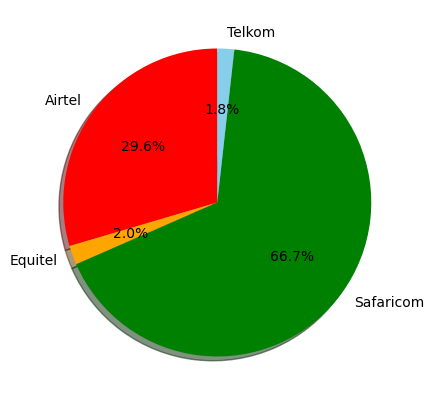

In [4]:
# ------------------------------
# 1. Mobile Penetration Context Validation
# ------------------------------

# Unique users
unique_callers = cdr_df['Caller id'].nunique()
unique_receivers = cdr_df['Receiver id'].nunique()
total_ids = pd.concat([cdr_df['Caller id'], cdr_df['Receiver id']]).nunique()

print(f"Unique Caller IDs: {unique_callers}")
print(f"Unique Receiver IDs: {unique_receivers}")
print(f"Total Unique IDs: {total_ids}")

# # Subscribers per operator
subscribers_per_operator = cdr_df.groupby('Caller company')['Caller id'].nunique()

# Pie chart: Subscribers per operator
plt.figure(figsize=(5,5))
subscribers_per_operator.plot(
    kind='pie',
    autopct='%1.1f%%',  # Shows percentage
    startangle=90,
    colors=['red','Orange','green','skyblue'],
    shadow=True
)
# plt.title('Percentage of Subscribers per Operator')
plt.ylabel('')  # Remove y-label for pie chart
plt.xlabel('')  # Remove y-label for pie chart
plt.show()


In [20]:
cdr_df.head(5)

,Caller id,Caller company,Receiver id,Receiver company,Timestamp,Duration s.,Type
0,84034,Safaricom,50880,Safaricom,2025-10-01 05:03:00,572,Voice
1,71646,Safaricom,50331,Safaricom,2025-10-01 05:08:00,1,Voice
2,84292,Safaricom,21396,Telkom,2025-10-01 05:11:00,205,Voice
3,98979,Safaricom,67072,Safaricom,2025-10-01 05:41:00,117,Voice
4,73312,Safaricom,53523,Airtel,2025-10-01 08:23:00,544,Voice


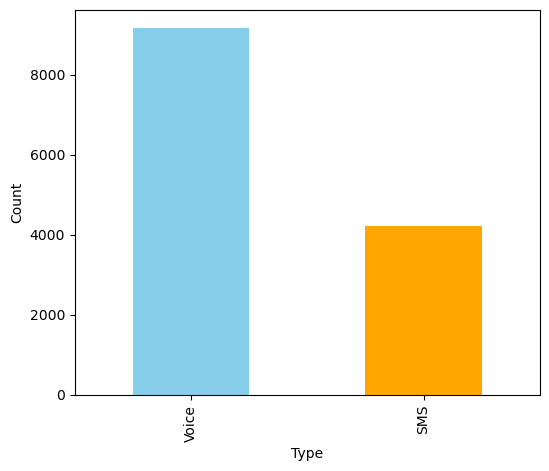

In [5]:
# ------------------------------
# 2. Voice and SMS Volume Distribution
# ------------------------------

# Total calls vs SMS
type_counts = cdr_df['Type'].value_counts()
plt.figure(figsize=(6,5))
type_counts.plot(kind='bar', color=['skyblue','orange'])
# plt.title('Total Calls vs SMS')
plt.ylabel('Count')
plt.show()

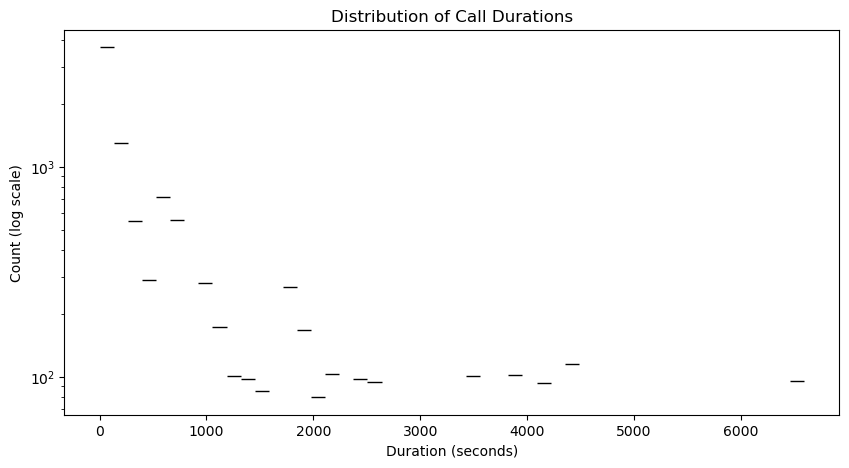

In [6]:
# Call duration distribution (Voice only)
voice_df = cdr_df[cdr_df['Type']=='Voice']
plt.figure(figsize=(10,5))
sns.histplot(voice_df['Duration s.'], bins=50, log_scale=(False, True), color='purple')
plt.title('Distribution of Call Durations')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count (log scale)')
plt.show()

In [18]:
voice_df.head(5)

,Caller id,Caller company,Receiver id,Receiver company,Timestamp,Duration s.,Type,Hour,Weekday
0,50378,Airtel,64200,Safaricom,2025-10-01 05:14:00,97,Voice,5,Wednesday
1,76130,Safaricom,37324,Airtel,2025-10-01 05:20:00,377,Voice,5,Wednesday
2,79999,Safaricom,95311,Safaricom,2025-10-01 05:25:00,1154,Voice,5,Wednesday
4,38842,Airtel,21902,Telkom,2025-10-01 05:43:00,20,Voice,5,Wednesday
6,56179,Safaricom,43191,Safaricom,2025-10-01 05:51:00,3004,Voice,5,Wednesday


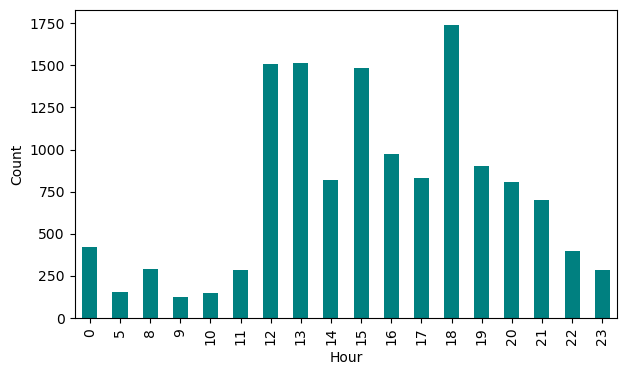

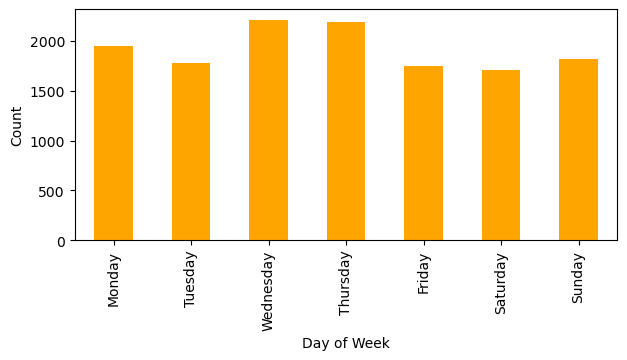

In [7]:
# ------------------------------
# 3. Temporal Patterns
# ------------------------------

# Extract hour and weekday
cdr_df['Hour'] = cdr_df['Timestamp'].dt.hour
cdr_df['Weekday'] = cdr_df['Timestamp'].dt.day_name()

# Hourly volume
hourly_counts = cdr_df.groupby('Hour').size()
plt.figure(figsize=(7,4))
hourly_counts.plot(kind='bar', color='teal')
# plt.title('Interactions by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.show()

# Weekday volume
weekday_counts = cdr_df.groupby('Weekday').size()
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_counts = weekday_counts.reindex(days_order)
plt.figure(figsize=(7,3))
weekday_counts.plot(kind='bar', color='orange')
# plt.title('Interactions by Weekday')
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.show()

# # Detect peak periods
# hourly_voice = voice_df.groupby('Hour').size()
# plt.figure(figsize=(7,4))
# hourly_voice.plot(kind='line', marker='o', color='purple', label='Voice')
# hourly_sms = cdr_df[cdr_df['Type']=='SMS'].groupby('Hour').size()
# hourly_sms.plot(kind='line', marker='x', color='green', label='SMS')
# plt.title('Hourly Call + SMS Volume')
# plt.xlabel('Hour')
# plt.ylabel('Count')
# plt.legend()
# plt.show()

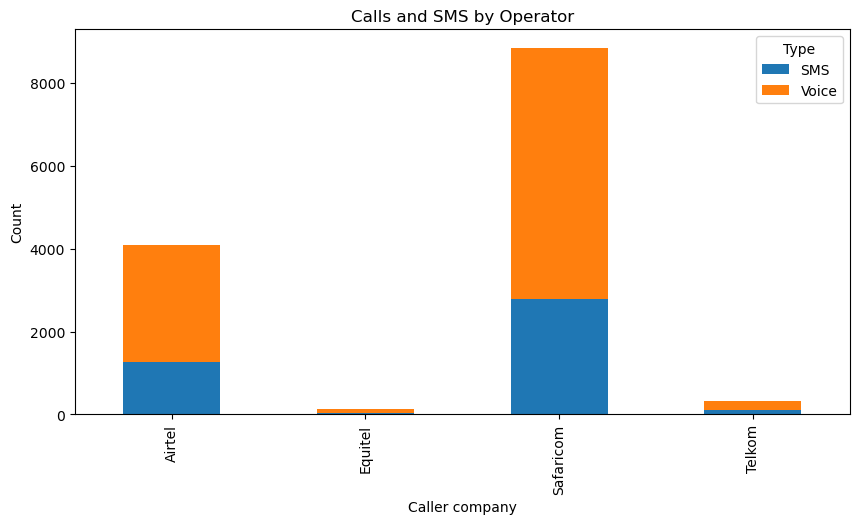

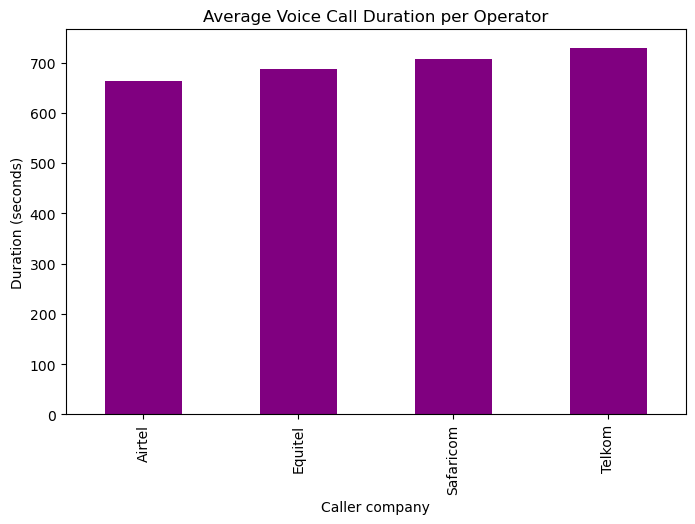

In [8]:
# ------------------------------
# 4. Operator Usage Patterns
# ------------------------------

# Calls/SMS by operator
operator_type_counts = cdr_df.groupby(['Caller company','Type']).size().unstack(fill_value=0)
operator_type_counts.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title('Calls and SMS by Operator')
plt.ylabel('Count')
plt.show()

# Average call duration by operator (Voice only)
avg_duration_op = voice_df.groupby('Caller company')['Duration s.'].mean()
plt.figure(figsize=(8,5))
avg_duration_op.plot(kind='bar', color='purple')
plt.title('Average Voice Call Duration per Operator')
plt.ylabel('Duration (seconds)')
plt.show()



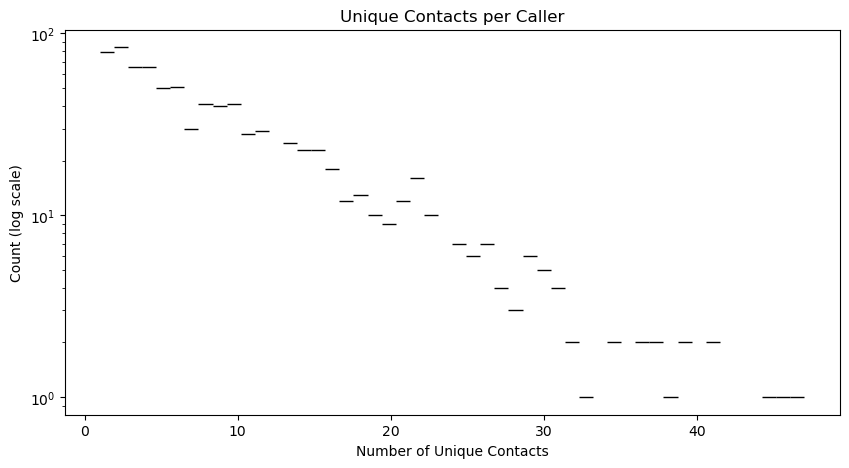

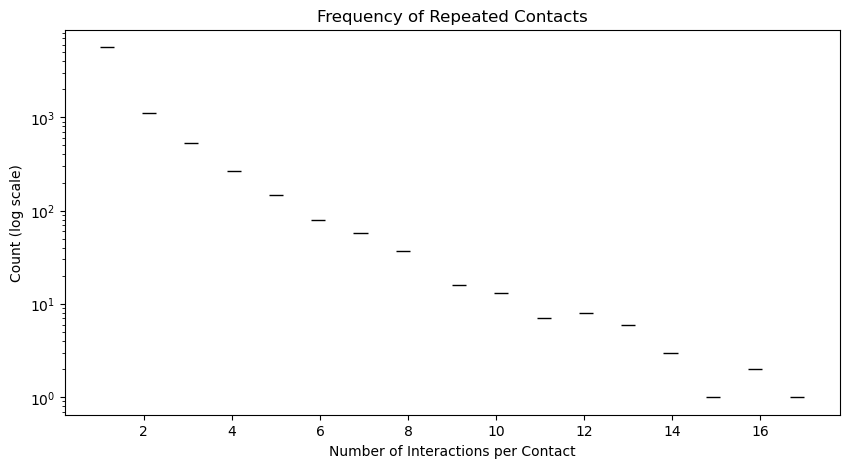

In [34]:
# ------------------------------
# 5. Interaction Diversity & Network Effects
# ------------------------------

# Unique contacts per user
unique_contacts = cdr_df.groupby('Caller id')['Receiver id'].nunique()
plt.figure(figsize=(10,5))
sns.histplot(unique_contacts, bins=50, log_scale=(False,True), color='skyblue')
plt.title('Unique Contacts per Caller')
plt.xlabel('Number of Unique Contacts')
plt.ylabel('Count (log scale)')
plt.show()

# Frequency of repeated contacts
contact_freq = cdr_df.groupby(['Caller id','Receiver id']).size().reset_index(name='Count')
plt.figure(figsize=(10,5))
sns.histplot(contact_freq['Count'], bins=50, log_scale=(False,True), color='salmon')
plt.title('Frequency of Repeated Contacts')
plt.xlabel('Number of Interactions per Contact')
plt.ylabel('Count (log scale)')
plt.show()



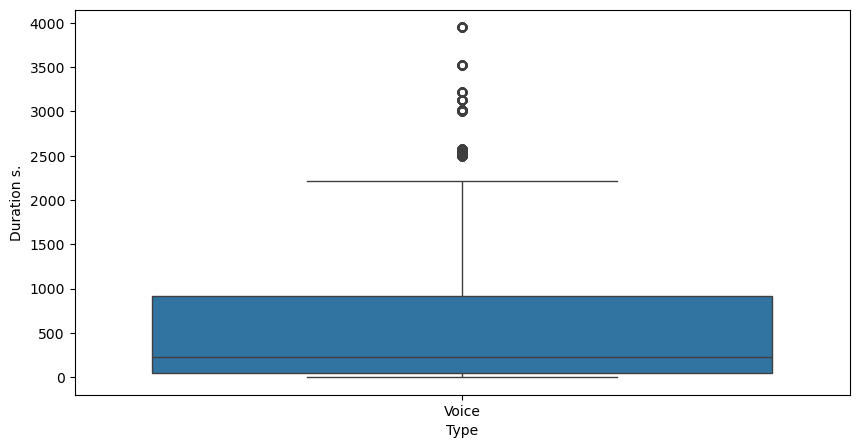

In [31]:
# ------------------------------
# Outlier & Anomaly Detection
# ------------------------------

# Call duration tails
plt.figure(figsize=(10,5))
sns.boxplot(x='Type', y='Duration s.', data=voice_df)
# plt.yscale('log')
# plt.title('Call/SMS Duration Boxplot (log scale)')
plt.show()

# # Identify unusual spikes
# daily_counts = cdr_df.groupby(cdr_df['Timestamp'].dt.date).size()
# plt.figure(figsize=(12,5))
# daily_counts.plot(kind='line', marker='o', color='red')
# plt.title('Daily Interaction Counts (Spike Detection)')
# plt.xlabel('Date')
# plt.ylabel('Count')
# plt.show()

# # Optional: top 5 days with unusually high activity
# print("Top 5 days with highest activity:")
# print(daily_counts.sort_values(ascending=False).head(5))

In [27]:
cdr_df.head()

,Caller id,Caller company,Receiver id,Receiver company,Timestamp,Duration s.,Type,Hour,Weekday
0,84034,Safaricom,50880,Safaricom,2025-10-01 05:03:00,572,Voice,5,Wednesday
1,71646,Safaricom,50331,Safaricom,2025-10-01 05:08:00,1,Voice,5,Wednesday
2,84292,Safaricom,21396,Telkom,2025-10-01 05:11:00,205,Voice,5,Wednesday
3,98979,Safaricom,67072,Safaricom,2025-10-01 05:41:00,117,Voice,5,Wednesday
4,73312,Safaricom,53523,Airtel,2025-10-01 08:23:00,544,Voice,8,Wednesday


In [27]:
!python -m pip install shap

   ---------------------------------------- 0.0/552.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/552.3 kB ? eta -:--:--
   ------------------ --------------------- 262.1/552.3 kB ? eta -:--:--
   ------------------ --------------------- 262.1/552.3 kB ? eta -:--:--
   ---------------------------------------- 552.3/552.3 kB 822.1 kB/s  0:00:00
   ---------------------------------------- 0.0/39.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/39.1 MB ? eta -:--:--
    --------------------------------------- 0.5/39.1 MB 1.4 MB/s eta 0:00:28
    --------------------------------------- 0.8/39.1 MB 1.3 MB/s eta 0:00:30
   - -------------------------------------- 1.3/39.1 MB 1.6 MB/s eta 0:00:24
   - -------------------------------------- 1.6/39.1 MB 1.6 MB/s eta 0:00:24
   - -------------------------------------- 1.8/39.1 MB 1.7 MB/s eta 0:00:23
   -- --------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [34]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
import json

# --- Sample feature data (CDR + SMS) ---
# Extract features per caller
features = df.groupby('caller_id').agg(
    num_calls=('duration_s.', 'count'),
    call_duration=('duration_s.', 'sum'),
    unique_contacts=('receiver_id', pd.Series.nunique),
    weekday_activity=('timestamp', lambda x: sum(x.dt.dayofweek < 5)),
    night_activity=('timestamp', lambda x: sum((x.dt.hour >= 0) & (x.dt.hour < 6)))
).reset_index()

# Strength of ties (proportion of calls to top contact)
def freq_ties(group):
    counts = group['receiver_id'].value_counts()
    if len(counts) == 0:
        return 0
    return counts.iloc[0] / counts.sum()

freq = df.groupby('caller_id').apply(freq_ties).reset_index(name='freq_ties')
features = features.merge(freq, on='caller_id')

# Night inactivity = 1 - proportion of calls during night
features['night_inactivity'] = 1 - (features['night_activity'] / features['num_calls'])

# Drop intermediate column
features = features.drop(columns=['night_activity'])
print(features)


     caller_id  num_calls  call_duration  unique_contacts  weekday_activity  \
0        20949         22           4897               18                14   
1        21396          2           1934                2                 2   
2        21902          5           3613                5                 5   
3        23101         42          19075               20                31   
4        23552          1             24                1                 1   
..         ...        ...            ...              ...               ...   
844     103655          5           1535                4                 5   
845     105881         46          15668               20                32   
846     105976          8           1647                7                 5   
847     106187         11           6873                9                 8   
848     108024         38          17175               19                28   

     freq_ties  night_inactivity  
0     0.136364  

In [ ]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df[feature_cols])
y = df['historical_score']

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# --- Train linear regression model ---
reg = LinearRegression()
reg.fit(X_train, y_train)

# --- Predict scores ---
y_pred = reg.predict(X_test)

# --- Accuracy metrics (fixed for older sklearn versions) ---
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # <-- replaced squared=False
r2 = r2_score(y_test, y_pred)

# print(f"Model Accuracy:\nMAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")

# # --- Explainable AI: Feature contributions using SHAP ---
# explainer = shap.Explainer(reg, X_train)
# shap_values = explainer(X_test)

# # Example: SHAP values for first test user
# shap.plots.waterfall(shap_values[0])

# # --- Generate per-user scorecards ---
# df_test = df.iloc[y_test.index].copy()
# df_test['predicted_score'] = y_pred

# def create_cdr_scorecard(row):
#     subMetrics = []
#     for i, feat in enumerate(feature_cols):
#         subMetrics.append({"label": feat.replace('_',' ').title(), "value": int(row[feat])})
#     return {
#         "user_id": int(row['caller_id']),
#         "categories": [
#             {
#                 "title": "CDR Score Card",
#                 "score": round(row['predicted_score'], 2),
#                 "type": "cdr",
#                 "subMetrics": subMetrics
#             }
#         ],
#         "history": []  # Can add historical scores if needed
#     }

# scorecards = [create_cdr_scorecard(row) for idx, row in df_test.iterrows()]

# # --- Save as JSON ---
# print(json.dumps(scorecards, indent=4))